# Notebook 2 -- Cross-model vote comparison

Descriptive comparison of the three models' votes, built entirely on the
tables produced by notebook 1 (`llm_vote_game_level.csv` +
`llm_vote_file_level.csv` per model, and the shared human tables under
`analysis/human_outcomes/`).

**Reading guide.** Every stochastic quantity uses the empirical distribution
over the 3 T=1 runs (see notebook 1's rationale); the greedy run is always a
separate categorical view. The human village votes serve as a *rough*
difficulty / social-signal proxy -- humans hold private night information and
their votes are an outcome of the same dialogue the models read, so agreement
with humans is compatible with either conformity or shared evidence. The
causal probes (part 2) are the arbiter; this notebook only measures *where the
votes land*.

Sections:

1. Corpus overview per model (accuracy proxies, circle rates, instability)
2. Model-model agreement (probabilistic + greedy, circle included)
3. Models vs. the crowd: aligned / dissociated games, vote destinations,
   bootstrap CIs on the diagnostic shares
4. Who gets wrongly accused: roles, the Tanner trap
5. Start-role vs end-role Werewolf (night-swap sensitivity)
6. Instability vs human ambiguity; success vs human solvability
7. Export: per-(model, game) table for the surrogate-model step


## Setup and loading

In [1]:
from pathlib import Path
from typing import Optional
from collections import Counter
from itertools import combinations
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

REPO_NAME = "masters_thesis_sdg"
MODEL_STAGE = "base"
PROMPT_DIR = "prompt_v4"
MIN_VILLAGE_VOTERS = 2
CIRCLE_VOTE_STRING = "No Werewolf"
N_BOOT = 5000
BOOT_SEED = 0
RNG = np.random.default_rng(BOOT_SEED)


def find_repo_root(start: Optional[Path] = None, repo_name: str = REPO_NAME) -> Path:
    current = (start or Path.cwd()).resolve()
    while True:
        if current.name == repo_name:
            return current
        if current.parent == current:
            raise FileNotFoundError(f"Could not find repo root {repo_name!r}")
        current = current.parent


def parse_json(value, default):
    if isinstance(value, (list, dict)):
        return value
    if not isinstance(value, str) or not value.strip():
        return default
    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return default


def short_model_label(folder_name: str) -> str:
    m = re.search(r"(\d+B)", folder_name)
    return m.group(1) if m else folder_name


REPO_ROOT = find_repo_root()
ANALYSIS_ROOT = REPO_ROOT / "analysis"
TABLES_REL = Path(MODEL_STAGE) / "voting" / PROMPT_DIR / "vote_stability" / "tables"
HUMAN_TABLES_DIR = ANALYSIS_ROOT / "human_outcomes" / PROMPT_DIR / "tables"
OUTPUT_DIR = ANALYSIS_ROOT / "cross_model" / "voting" / PROMPT_DIR / "tables"
print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: C:\Users\annab\Documents\GitHub\masters_thesis_sdg


In [2]:
# Discover per-model tables produced by notebook 1.
game_frames, file_frames = [], []
for model_dir in sorted(ANALYSIS_ROOT.iterdir()):
    tables = model_dir / TABLES_REL
    if not (tables / "llm_vote_game_level.csv").exists():
        continue
    label = short_model_label(model_dir.name)
    g = pd.read_csv(tables / "llm_vote_game_level.csv")
    g["model"] = label
    for col, default in [("player_names", []), ("start_roles", []), ("end_roles", []),
                         ("correct_player_names", []), ("stoch_vote_distribution", {})]:
        g[col] = g[col].apply(lambda v: parse_json(v, default))
    game_frames.append(g)
    f = pd.read_csv(tables / "llm_vote_file_level.csv")
    f["model"] = label
    file_frames.append(f)

games = pd.concat(game_frames, ignore_index=True)
votes = pd.concat(file_frames, ignore_index=True)
MODELS = sorted(games["model"].unique())
print(f"Models: {MODELS}")
print(f"game-level rows: {len(games)} | file-level rows: {len(votes)}")

# Human tables (shared, model-agnostic).
village = pd.read_csv(HUMAN_TABLES_DIR / "village_vote_dispersion.csv")
village["village_vote_counts"] = village["village_vote_counts"].apply(lambda v: parse_json(v, {}))
village["village_top_target_names"] = village["village_top_target_names"].apply(lambda v: set(parse_json(v, [])))
village = village[village["n_village_aligned_votes"] >= MIN_VILLAGE_VOTERS].copy()
human_outcomes = pd.read_csv(HUMAN_TABLES_DIR / "human_game_outcomes.csv")
print(f"human village games kept (>= {MIN_VILLAGE_VOTERS} voters): {len(village)}")


Models: ['2B', '31B', '4B']
game-level rows: 573 | file-level rows: 2292
human village games kept (>= 2 voters): 169


In [3]:
# Merge game-level model rows with human info; classify games.
def classify_game(modal_targets: set, wolves: set) -> str:
    # aligned: every modal target is a Werewolf; dissociated: none is;
    # mixed_tie: a tie containing both. Diagnostic analyses use dissociated only.
    if not wolves:
        return "no_werewolf"
    if not modal_targets:
        return "no_human_votes"
    hits = modal_targets & wolves
    if hits == modal_targets:
        return "aligned"
    if not hits:
        return "dissociated"
    return "mixed_tie"


games["wolves"] = games["correct_player_names"].apply(set)
merged = games.merge(
    village[["game_id", "n_village_aligned_votes", "village_vote_counts",
             "village_top_target_names", "village_top_share",
             "village_vote_entropy", "village_modal_correct"]],
    on="game_id", how="inner",
)
merged["game_class"] = [
    classify_game(r["village_top_target_names"], r["wolves"]) for _, r in merged.iterrows()
]

one_model = merged[merged["model"] == MODELS[0]]
print("Game classification (games with human data, per game):")
display(one_model["game_class"].value_counts().rename_axis("game_class").to_frame("n_games"))
print(f"(model, game) rows: {len(merged)}; per model: {merged.groupby('model').size().to_dict()}")


Game classification (games with human data, per game):


,n_games
game_class,
aligned,71
dissociated,47
mixed_tie,28
no_werewolf,23


(model, game) rows: 507; per model: {'2B': 169, '31B': 169, '4B': 169}


## 1. Corpus overview per model

Accuracy proxies (mean `p_correct`, greedy accuracy), circle-vote behavior, and
within-model instability, over all evaluable games. Circle voting is a real
epistemic stance ("I see no werewolf"), not noise, so it is reported, not
dropped.


In [4]:
def stoch_circle_mass(dist: dict) -> float:
    return float(dist.get(CIRCLE_VOTE_STRING, 0.0))


overview = (
    games.assign(circle_mass=games["stoch_vote_distribution"].apply(stoch_circle_mass),
                 greedy_is_circle=games["greedy_vote"] == CIRCLE_VOTE_STRING)
    .groupby("model")
    .agg(n_games=("game_id", "size"),
         mean_p_correct=("p_correct", "mean"),
         greedy_accuracy=("greedy_correct", "mean"),
         mean_stoch_entropy=("stoch_entropy", "mean"),
         stoch_circle_mass=("circle_mass", "mean"),
         greedy_circle_rate=("greedy_is_circle", "mean"),
         strict_majority_rate=("has_strict_majority", "mean"))
    .round(3)
)
display(overview)


,n_games,mean_p_correct,greedy_accuracy,mean_stoch_entropy,stoch_circle_mass,greedy_circle_rate,strict_majority_rate
model,,,,,,,
2B,191,0.406,0.366,0.386,0.229,0.251,0.885
31B,191,0.417,0.440,0.275,0.120,0.126,0.932
4B,191,0.412,0.408,0.338,0.059,0.094,0.911


## 2. Model-model agreement

Probabilistic agreement between models A and B on one game = the probability
that one T=1 sample from each lands on the same target,
`sum_x p_A(x) * p_B(x)` (circle counted as a target). Averaged over shared
games. The greedy matrix is the categorical counterpart. A reference point for
each model pair is the mean **self-agreement** `sum_x p_A(x)^2` of the two
models -- two independent samples from the *same* model agree only that often,
so between-model agreement should be read against it, not against 1.0.


In [5]:
def expected_agreement(p_a: dict, p_b: dict) -> float:
    return float(sum(p_a.get(k, 0.0) * v for k, v in p_b.items()))


dist_by_model_game = {
    (r["model"], r["game_id"]): r["stoch_vote_distribution"]
    for _, r in games.iterrows() if r["n_valid_stochastic"] > 0
}
greedy_by_model_game = {
    (r["model"], r["game_id"]): r["greedy_vote"]
    for _, r in games.iterrows() if pd.notna(r["greedy_vote"])
}
all_game_ids = games["game_id"].unique()

prob_agree = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)
greedy_agree = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)
for m in MODELS:
    self_vals = [expected_agreement(d, d) for (mm, g), d in dist_by_model_game.items() if mm == m]
    prob_agree.loc[m, m] = np.mean(self_vals)  # self-agreement (Simpson)
    greedy_agree.loc[m, m] = 1.0
for a, b in combinations(MODELS, 2):
    pvals, gvals = [], []
    for gid in all_game_ids:
        da, db = dist_by_model_game.get((a, gid)), dist_by_model_game.get((b, gid))
        if da is not None and db is not None:
            pvals.append(expected_agreement(da, db))
        ga, gb = greedy_by_model_game.get((a, gid)), greedy_by_model_game.get((b, gid))
        if ga is not None and gb is not None:
            gvals.append(ga == gb)
    prob_agree.loc[a, b] = prob_agree.loc[b, a] = np.mean(pvals) if pvals else np.nan
    greedy_agree.loc[a, b] = greedy_agree.loc[b, a] = np.mean(gvals) if gvals else np.nan

print("Probabilistic agreement (diagonal = self-agreement of two T=1 samples):")
display((prob_agree * 100).round(1))
print("Greedy vote agreement:")
display((greedy_agree * 100).round(1))


Probabilistic agreement (diagonal = self-agreement of two T=1 samples):


,2B,31B,4B
2B,74.1,43.0,51.0
31B,43.0,81.5,41.9
4B,51.0,41.9,77.3


Greedy vote agreement:


,2B,31B,4B
2B,100.0,41.4,53.9
31B,41.4,100.0,46.1
4B,53.9,46.1,100.0


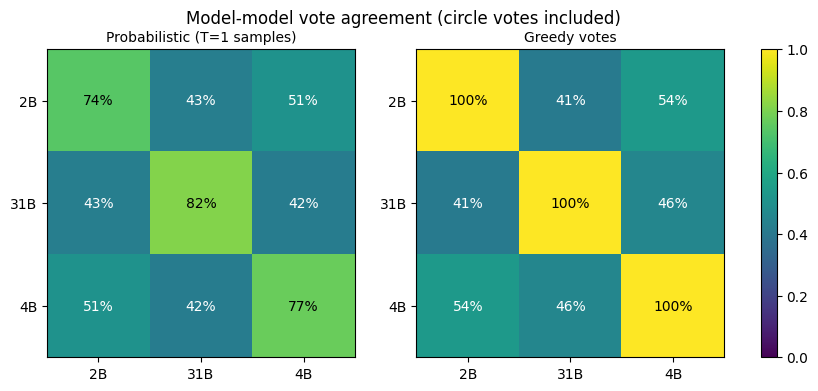

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, mat, title in [(axes[0], prob_agree, "Probabilistic (T=1 samples)"),
                       (axes[1], greedy_agree, "Greedy votes")]:
    im = ax.imshow(mat.values.astype(float), vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS)
    ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
    for i in range(len(MODELS)):
        for j in range(len(MODELS)):
            v = mat.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.0%}", ha="center", va="center",
                        color="white" if v < 0.6 else "black")
    ax.set_title(title, fontsize=10)
fig.suptitle("Model-model vote agreement (circle votes included)")
fig.colorbar(im, ax=axes, fraction=0.03)
plt.show()


## 3. Models vs. the crowd

The human-referenced partition: **aligned** games (human modal target is a
Werewolf; non-diagnostic -- crowd-following and correct deduction predict the
same vote) vs. **dissociated** games (the crowd's modal pick is wrong; the only
games where the two hypotheses separate). Per model and class, the stochastic
vote mass is decomposed by destination, with precedence
werewolf > human_modal > other_human_target > unvoted (circle mass reported as
its own row since it names nobody).


,game_class,model,n_games,werewolf,human_modal,other_human_target,unvoted_player,circle
0,aligned,2B,71,0.528,0.000,0.056,0.265,0.150
1,aligned,31B,71,0.615,0.000,0.066,0.268,0.052
2,aligned,4B,71,0.592,0.000,0.038,0.352,0.019
3,dissociated,2B,47,0.248,0.411,0.021,0.149,0.170
4,dissociated,31B,47,0.184,0.475,0.007,0.248,0.085
5,dissociated,4B,47,0.255,0.411,0.028,0.284,0.021


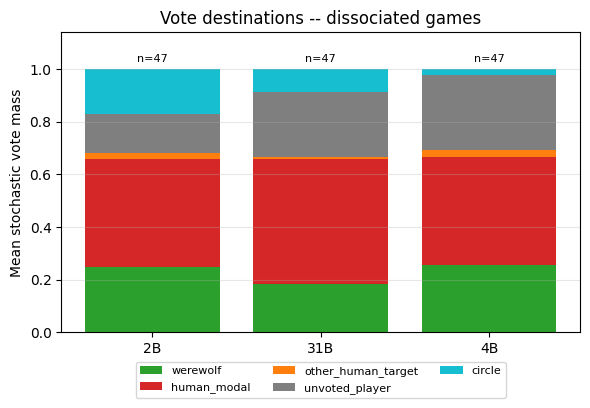

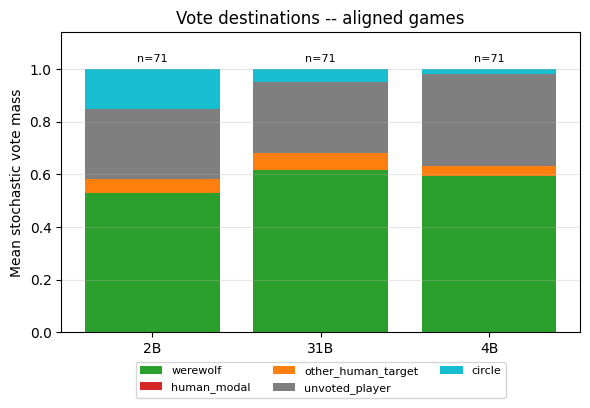

In [7]:
DEST_CATEGORIES = ["werewolf", "human_modal", "other_human_target", "unvoted_player", "circle"]
DEST_COLORS = {"werewolf": "#2ca02c", "human_modal": "#d62728",
               "other_human_target": "#ff7f0e", "unvoted_player": "#7f7f7f", "circle": "#17becf"}


def destination_shares(row: pd.Series) -> Optional[dict]:
    dist = row["stoch_vote_distribution"]
    if not dist:
        return None
    shares = dict.fromkeys(DEST_CATEGORIES, 0.0)
    for label, mass in dist.items():
        if label == CIRCLE_VOTE_STRING:
            shares["circle"] += mass
        elif label in row["wolves"]:
            shares["werewolf"] += mass
        elif label in row["village_top_target_names"]:
            shares["human_modal"] += mass
        elif label in row["village_vote_counts"]:
            shares["other_human_target"] += mass
        else:
            shares["unvoted_player"] += mass
    return shares


share_rows = []
for _, r in merged.iterrows():
    s = destination_shares(r)
    if s is None:
        continue
    share_rows.append({"model": r["model"], "game_id": r["game_id"], "game_class": r["game_class"], **s})
shares_df = pd.DataFrame(share_rows)

dest_summary = (
    shares_df[shares_df["game_class"].isin(["dissociated", "aligned"])]
    .groupby(["game_class", "model"])
    .agg(n_games=("werewolf", "size"), **{c: (c, "mean") for c in DEST_CATEGORIES})
    .round(3).reset_index()
)
display(dest_summary)

for game_class in ["dissociated", "aligned"]:
    sub = dest_summary[dest_summary["game_class"] == game_class].set_index("model").reindex(MODELS).dropna(how="all")
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=(6, 4.2))
    x = np.arange(len(sub)); bottom = np.zeros(len(sub))
    for cat in DEST_CATEGORIES:
        vals = sub[cat].values.astype(float)
        ax.bar(x, vals, bottom=bottom, label=cat, color=DEST_COLORS[cat])
        bottom += vals
    for i, (_, r) in enumerate(sub.iterrows()):
        ax.text(i, 1.02, f"n={int(r['n_games'])}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(sub.index); ax.set_ylim(0, 1.14)
    ax.set_ylabel("Mean stochastic vote mass")
    ax.set_title(f"Vote destinations -- {game_class} games")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()


### Bootstrap CIs on the diagnostic shares

Per-model 95% percentile CIs (resampling games) on the werewolf and
human-modal shares in dissociated games, and **paired** between-model
differences (resampling only games both models share, which holds game
difficulty fixed). A ranking is quotable only where the paired CI excludes 0.


In [8]:
def bootstrap_mean_ci(values, n_boot=N_BOOT, alpha=0.05):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    idx = RNG.integers(0, len(values), size=(n_boot, len(values)))
    boot = values[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(values.mean()), float(lo), float(hi)


diss = shares_df[shares_df["game_class"] == "dissociated"]
ci_rows = []
for m in MODELS:
    sub = diss[diss["model"] == m]
    for cat in ["werewolf", "human_modal"]:
        mean, lo, hi = bootstrap_mean_ci(sub[cat].values)
        ci_rows.append({"model": m, "category": cat, "n_games": len(sub),
                        "mean": mean, "ci_low": lo, "ci_high": hi})
display(pd.DataFrame(ci_rows).round(3))

pair_rows = []
for cat in ["werewolf", "human_modal"]:
    piv = diss.pivot_table(index="game_id", columns="model", values=cat)
    for a, b in combinations(MODELS, 2):
        if a not in piv.columns or b not in piv.columns:
            continue
        paired = piv[[a, b]].dropna()
        if paired.empty:
            continue
        mean, lo, hi = bootstrap_mean_ci((paired[a] - paired[b]).values)
        pair_rows.append({"model_a": a, "model_b": b, "category": cat,
                          "n_paired_games": len(paired), "mean_diff": mean,
                          "ci_low": lo, "ci_high": hi,
                          "excludes_zero": bool(lo > 0 or hi < 0)})
print("Paired between-model differences (A - B), 95% bootstrap CI:")
display(pd.DataFrame(pair_rows).round(3))


,model,category,n_games,mean,ci_low,ci_high
0,2B,werewolf,47,0.248,0.149,0.355
1,2B,human_modal,47,0.411,0.298,0.532
2,31B,werewolf,47,0.184,0.099,0.277
3,31B,human_modal,47,0.475,0.348,0.596
4,4B,werewolf,47,0.255,0.149,0.369
5,4B,human_modal,47,0.411,0.291,0.539


Paired between-model differences (A - B), 95% bootstrap CI:


,model_a,model_b,category,n_paired_games,mean_diff,ci_low,ci_high,excludes_zero
0,2B,31B,werewolf,47,0.064,-0.050,0.170,False
1,2B,4B,werewolf,47,-0.007,-0.099,0.085,False
2,31B,4B,werewolf,47,-0.071,-0.191,0.050,False
3,2B,31B,human_modal,47,-0.064,-0.184,0.050,False
4,2B,4B,human_modal,47,-0.000,-0.085,0.085,False
5,31B,4B,human_modal,47,0.064,-0.071,0.199,False


## 4. Who gets wrongly accused: roles and the Tanner trap

Among stochastic vote mass on named, non-Werewolf targets, the distribution
over the target's **end role** (mass-weighted, so a 2/3 vote counts as 2/3).
Voting the Tanner is a specific self-inflicted loss, so it is called out, and
the follow-up asks: on games where the *crowd's* modal target is a Tanner, do
the models walk onto the same trap?


Share of wrong (named, non-Werewolf) stochastic vote mass, by end role of the accused:


role,Robber,Tanner,Villager,Troublemaker,Seer,Insomniac,Minion,Hunter,Mason,Drunk,Center Card,Doppelganger
model,,,,,,,,,,,,
2B,24.1,22.7,13.8,12.2,8.9,9.7,4.1,3.7,0.4,0.4,0.0,0.0
31B,25.4,21.4,13.6,14.9,10.2,3.4,4.4,2.7,1.0,1.4,0.7,1.0
4B,23.2,16.8,14.3,14.3,15.2,6.0,3.5,4.8,1.0,0.3,0.6,0.0


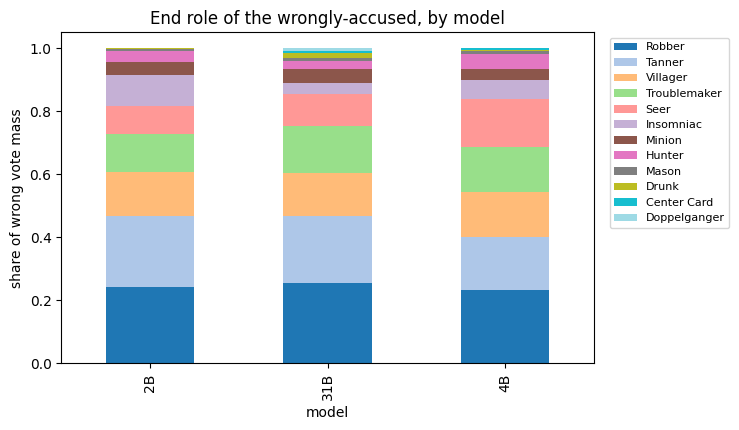

In [9]:
def role_of(label: str, row: pd.Series) -> Optional[str]:
    names = row["player_names"]
    if label in names:
        return row["end_roles"][names.index(label)]
    return None


wrong_role_rows = []
for _, r in games.iterrows():
    for label, mass in r["stoch_vote_distribution"].items():
        if label == CIRCLE_VOTE_STRING or label in r["wolves"]:
            continue
        role = role_of(label, r)
        if role is not None:
            wrong_role_rows.append({"model": r["model"], "role": role, "mass": mass})
wrong_roles = pd.DataFrame(wrong_role_rows)
role_share = wrong_roles.groupby(["model", "role"])["mass"].sum().rename("mass").reset_index()
role_share["share"] = role_share["mass"] / role_share.groupby("model")["mass"].transform("sum")
pivot = role_share.pivot_table(index="model", columns="role", values="share", fill_value=0).reindex(MODELS)
pivot = pivot[pivot.sum().sort_values(ascending=False).index]
print("Share of wrong (named, non-Werewolf) stochastic vote mass, by end role of the accused:")
display((pivot * 100).round(1))

pivot.plot(kind="bar", stacked=True, figsize=(7.5, 4.4), colormap="tab20")
plt.ylabel("share of wrong vote mass"); plt.title("End role of the wrongly-accused, by model")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


### Normalizing by role availability

Raw shares are confounded by base rates: not every role appears in every game,
and frequent roles (Robber, Villager) collect wrong votes partly because they
are simply *there*. For each model and role, the observed share of wrong vote
mass is compared with the role's **opportunity share** -- the fraction of
non-Werewolf seats that role occupies, weighted per game by how much wrong
mass the model actually spent there. Their ratio is a **lift**: 1 = accused
exactly as often as random accusation among non-Werewolves would predict,
2 = accused twice as often per seat available. Roles with tiny opportunity
shares get noisy lifts, so opportunity is reported alongside.


Accusation lift by end role (1 = proportional to seat availability):


model,2B,31B,4B,mean_opportunity_share
role,,,,
Robber,1.19,1.22,1.21,20.1
Troublemaker,0.64,0.80,0.71,19.4
Seer,0.56,0.67,0.91,15.9
Tanner,1.49,1.46,1.19,14.7
Villager,1.38,1.31,1.27,10.5
Insomniac,1.25,0.44,0.87,7.5
Minion,0.78,0.91,0.73,4.9
Hunter,1.07,1.22,1.82,2.7
Mason,0.52,0.50,0.87,1.3


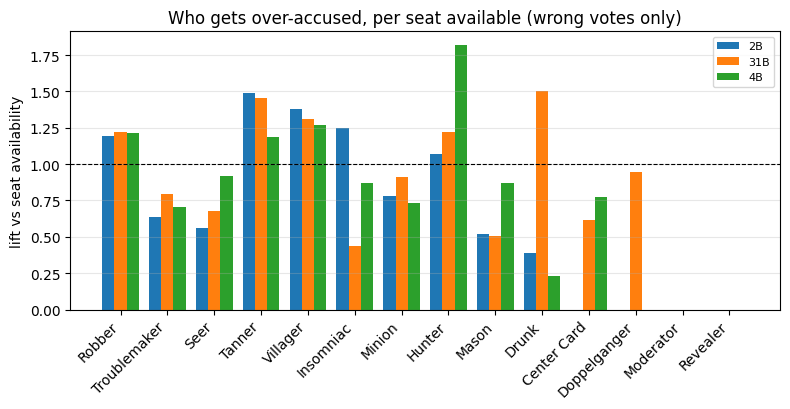

In [10]:
lift_rows = []
for _, r in games.iterrows():
    dist = r["stoch_vote_distribution"]
    names, ends = r["player_names"], r["end_roles"]
    nonwolf_seats = [role for role in ends if role != "Werewolf"]
    if not dist or not nonwolf_seats:
        continue
    wrong_mass = sum(v for k, v in dist.items()
                     if k != CIRCLE_VOTE_STRING and k not in r["wolves"] and k in names)
    if wrong_mass == 0:
        continue
    seat_counts = Counter(nonwolf_seats)
    for role, n_seats in seat_counts.items():
        observed = sum(v for k, v in dist.items()
                       if k in names and ends[names.index(k)] == role and k not in r["wolves"])
        expected = wrong_mass * n_seats / len(nonwolf_seats)
        lift_rows.append({"model": r["model"], "role": role,
                          "observed_mass": observed, "expected_mass": expected})

lift_df = (pd.DataFrame(lift_rows).groupby(["model", "role"])[["observed_mass", "expected_mass"]]
           .sum().reset_index())
totals = lift_df.groupby("model")["observed_mass"].transform("sum")
lift_df["observed_share"] = lift_df["observed_mass"] / totals
lift_df["opportunity_share"] = lift_df["expected_mass"] / lift_df.groupby("model")["expected_mass"].transform("sum")
lift_df["lift"] = lift_df["observed_mass"] / lift_df["expected_mass"]

lift_pivot = lift_df.pivot_table(index="role", columns="model", values="lift").reindex(
    lift_df.groupby("role")["expected_mass"].sum().sort_values(ascending=False).index)
opp = lift_df.groupby("role")["opportunity_share"].mean().reindex(lift_pivot.index)
table = lift_pivot.round(2)
table["mean_opportunity_share"] = (opp * 100).round(1)
print("Accusation lift by end role (1 = proportional to seat availability):")
display(table)

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(lift_pivot)); w = 0.26
for k, m in enumerate(MODELS):
    if m in lift_pivot.columns:
        ax.bar(x + (k - 1) * w, lift_pivot[m].values, w, label=m)
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.set_xticks(x); ax.set_xticklabels(lift_pivot.index, rotation=45, ha="right")
ax.set_ylabel("lift vs seat availability")
ax.set_title("Who gets over-accused, per seat available (wrong votes only)")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
TANNER = "Tanner"

tanner_rows = []
for _, r in merged.iterrows():
    names = r["player_names"]
    tanners = {names[i] for i, role in enumerate(r["end_roles"]) if role == TANNER}
    crowd_tanners = r["village_top_target_names"] & tanners
    if not crowd_tanners:
        continue
    dist = r["stoch_vote_distribution"]
    tanner_rows.append({
        "model": r["model"], "game_id": r["game_id"],
        "stoch_mass_on_crowd_tanner": sum(dist.get(t, 0.0) for t in crowd_tanners),
        "greedy_followed": r["greedy_vote"] in crowd_tanners if pd.notna(r["greedy_vote"]) else np.nan,
    })
tanner_df = pd.DataFrame(tanner_rows)
if tanner_df.empty:
    print("No games where the crowd's modal target is a Tanner.")
else:
    summary = (tanner_df.groupby("model")
               .agg(n_games=("game_id", "size"),
                    mean_stoch_mass_on_tanner=("stoch_mass_on_crowd_tanner", "mean"),
                    greedy_follow_rate=("greedy_followed", "mean")).round(3))
    print("Games where the crowd's modal target is a Tanner -- do the models follow?")
    display(summary)


Games where the crowd's modal target is a Tanner -- do the models follow?


,n_games,mean_stoch_mass_on_tanner,greedy_follow_rate
model,,,
2B,31,0.333,0.355
31B,31,0.312,0.258
4B,31,0.323,0.290


## 5. Start-role vs end-role Werewolf

Correctness is scored on end roles (the win condition), but the dialogue was
produced by players acting on their **start** roles. Mass on a start-Werewolf
who ended otherwise = a defensible read punished by a night swap. This bounds
how much of the "wrong" mass is defensible; it does not certify the reasoning
(part 2 does that).


In [12]:
def ww_names(names: list, roles: list) -> set:
    return {names[i] for i, role in enumerate(roles) if role == "Werewolf"}


start_rows = []
for _, r in games.iterrows():
    dist = r["stoch_vote_distribution"]
    if not dist:
        continue
    start_ww = ww_names(r["player_names"], r["start_roles"])
    end_ww = r["wolves"]
    named = {k: v for k, v in dist.items() if k != CIRCLE_VOTE_STRING}
    start_rows.append({
        "model": r["model"], "game_id": r["game_id"],
        "swap_game": bool(start_ww != end_ww),
        "p_end_ww": sum(v for k, v in named.items() if k in end_ww),
        "p_start_ww": sum(v for k, v in named.items() if k in start_ww),
        "p_start_not_end": sum(v for k, v in named.items() if k in start_ww and k not in end_ww),
        "p_wrong": sum(v for k, v in named.items() if k not in end_ww),
    })
start_df = pd.DataFrame(start_rows)
n_swaps = start_df[start_df["model"] == MODELS[0]]["swap_game"].sum()
print(f"Games where the Werewolf identity moves start -> end: {int(n_swaps)}")

summary = (start_df.groupby("model")
           .agg(n_games=("game_id", "size"), p_end_ww=("p_end_ww", "mean"),
                p_start_ww=("p_start_ww", "mean"),
                p_start_not_end=("p_start_not_end", "mean")).round(3))
summary["defensible_share_of_wrong"] = (
    start_df.groupby("model").apply(
        lambda g: g["p_start_not_end"].sum() / g["p_wrong"].sum() if g["p_wrong"].sum() > 0 else np.nan,
        include_groups=False)
).round(3)
display(summary)


Games where the Werewolf identity moves start -> end: 73


,n_games,p_end_ww,p_start_ww,p_start_not_end,defensible_share_of_wrong
model,,,,,
2B,191,0.341,0.326,0.089,0.207
31B,191,0.365,0.351,0.106,0.207
4B,191,0.391,0.384,0.112,0.203


## 6. Instability vs human ambiguity; success vs human solvability

Left: does a model's run-to-run entropy rise on the games that split the human
table (Spearman)? Right: `p_correct` conditioned on whether the humans' modal
vote found the Werewolf. Caution: in this corpus "humans failed" and "the
Werewolf played deceptively" are nearly the same axis, so the gap conflates
social signal and difficulty -- this is a description, not a mechanism.


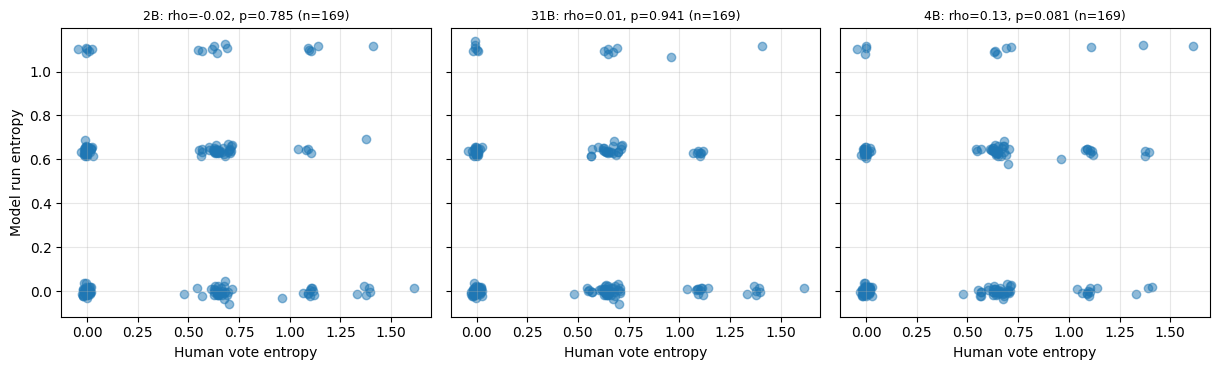

,model,village_modal_correct,n_games,mean_p_correct
0,2B,False,70,0.314
1,2B,True,99,0.463
2,31B,False,70,0.252
3,31B,True,99,0.542
4,4B,False,70,0.214
5,4B,True,99,0.542


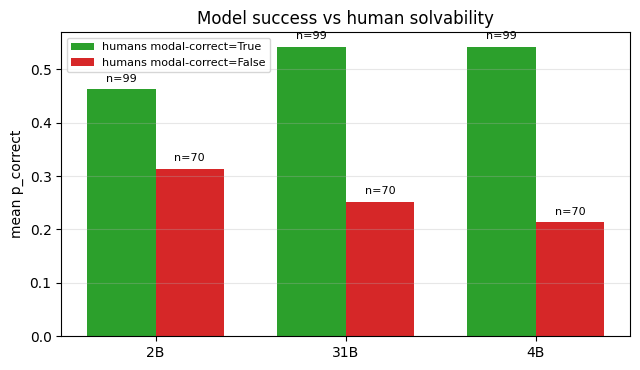

In [13]:
ent = merged[merged["n_valid_stochastic"] >= 2].copy()
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.1 * len(MODELS), 3.8), sharey=True, squeeze=False)
for ax, m in zip(axes[0], MODELS):
    sub = ent[ent["model"] == m].dropna(subset=["village_vote_entropy", "stoch_entropy"])
    if len(sub) < 3 or sub["stoch_entropy"].nunique() < 2 or sub["village_vote_entropy"].nunique() < 2:
        ax.set_title(f"{m}: insufficient variation", fontsize=9)
        continue
    rho, pval = spearmanr(sub["village_vote_entropy"], sub["stoch_entropy"])
    jit = np.random.default_rng(0).normal(0, 0.015, size=(len(sub), 2))
    ax.scatter(sub["village_vote_entropy"] + jit[:, 0], sub["stoch_entropy"] + jit[:, 1], alpha=0.5)
    ax.set_title(f"{m}: rho={rho:.2f}, p={pval:.3f} (n={len(sub)})", fontsize=9)
    ax.set_xlabel("Human vote entropy"); ax.grid(alpha=0.3)
axes[0][0].set_ylabel("Model run entropy")
plt.tight_layout(); plt.show()

solv = merged[merged["n_valid_stochastic"] > 0].copy()
solv["village_modal_correct"] = solv["village_modal_correct"].astype(bool)
solv_summary = (solv.groupby(["model", "village_modal_correct"])
                .agg(n_games=("p_correct", "size"), mean_p_correct=("p_correct", "mean"))
                .round(3).reset_index())
display(solv_summary)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
x = np.arange(len(MODELS)); w = 0.36
for off, flag, color in [(-w / 2, True, "#2ca02c"), (w / 2, False, "#d62728")]:
    vals, ns = [], []
    for m in MODELS:
        s = solv_summary[(solv_summary["model"] == m) & (solv_summary["village_modal_correct"] == flag)]
        vals.append(s["mean_p_correct"].iloc[0] if len(s) else np.nan)
        ns.append(int(s["n_games"].iloc[0]) if len(s) else 0)
    bars = ax.bar(x + off, vals, w, label=f"humans modal-correct={flag}", color=color)
    for bar, n in zip(bars, ns):
        if not np.isnan(bar.get_height()):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"n={n}",
                    ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel("mean p_correct"); ax.set_title("Model success vs human solvability")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


### Solvability split by `has_werewolf`

The human-failed group mixes two very different situations: werewolf-present
games the crowd misread, and no-werewolf games where the crowd wrongly voted
someone (there, `p_correct` is earned by *circle-voting*). A model with a high
circle rate can therefore lead the human-failed column without deducing
anything. Splitting by `has_werewolf` separates "found the wolf against the
crowd" from "abstained and abstaining happened to be right".


In [14]:
solv2 = merged[merged["n_valid_stochastic"] > 0].copy()
solv2["village_modal_correct"] = solv2["village_modal_correct"].astype(bool)
split = (solv2.groupby(["model", "has_werewolf", "village_modal_correct"])
         .agg(n_games=("p_correct", "size"), mean_p_correct=("p_correct", "mean"))
         .round(3).reset_index())
print("p_correct by human solvability, split by whether a Werewolf exists:")
display(split.pivot_table(index=["has_werewolf", "village_modal_correct"],
                          columns="model", values="mean_p_correct"))
print("n_games per cell:")
display(split.pivot_table(index=["has_werewolf", "village_modal_correct"],
                          columns="model", values="n_games"))

hard = split[(split["has_werewolf"] == True) & (split["village_modal_correct"] == False)]
print("Werewolf-present games the humans failed (the deduction test):")
display(hard[["model", "n_games", "mean_p_correct"]])


p_correct by human solvability, split by whether a Werewolf exists:


model                                  2B    31B     4B
has_werewolf village_modal_correct                     
False        False                  0.449  0.391  0.130
True         False                  0.248  0.184  0.255
             True                   0.463  0.542  0.542

n_games per cell:


model                                 2B   31B    4B
has_werewolf village_modal_correct                  
False        False                  23.0  23.0  23.0
True         False                  47.0  47.0  47.0
             True                   99.0  99.0  99.0

Werewolf-present games the humans failed (the deduction test):


,model,n_games,mean_p_correct
1,2B,47,0.248
4,31B,47,0.184
7,4B,47,0.255


## 7. Export for the surrogate-model step

One row per (model, game) with the behavioral quantities computed above --
usable directly as targets/features when predicting votes.


In [15]:
export = merged[["model", "game_id", "source", "session_name", "game_key", "game_class",
                 "n_valid_stochastic", "p_correct", "stoch_entropy",
                 "greedy_vote", "greedy_correct",
                 "n_village_aligned_votes", "village_top_share",
                 "village_vote_entropy", "village_modal_correct"]].copy()
export = export.merge(shares_df.drop(columns=["game_class"]), on=["model", "game_id"], how="left")
export = export.merge(start_df[["model", "game_id", "swap_game", "p_start_ww", "p_start_not_end"]],
                      on=["model", "game_id"], how="left")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUTPUT_DIR / "cross_model_game_features.csv"
export.to_csv(out_path, index=False)
print(f"saved {len(export)} rows -> {out_path.relative_to(REPO_ROOT)}")
display(export.head(3))


saved 507 rows -> analysis\cross_model\voting\prompt_v4\tables\cross_model_game_features.csv


,model,game_id,source,session_name,game_key,game_class,n_valid_stochastic,p_correct,stoch_entropy,greedy_vote,...,village_vote_entropy,village_modal_correct,werewolf,human_modal,other_human_target,unvoted_player,circle,swap_game,p_start_ww,p_start_not_end
0,31B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game1,dissociated,3,0.333333,0.636514,Brent,...,0.636514,False,0.333333,0.0,0.0,0.666667,0.0,True,0.666667,0.666667
1,31B,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,Ego4D,0c2659db-7bd4-4b37-9b08-4e247befe382,Game4,dissociated,3,0.000000,-0.000000,Elliot,...,0.636514,False,0.000000,0.0,0.0,1.000000,0.0,False,0.000000,0.000000
2,31B,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,Ego4D,0c2659db-7bd4-4b37-9b08-4e247befe382,Game5,aligned,3,0.000000,-0.000000,Sian,...,0.562335,True,0.000000,0.0,0.0,1.000000,0.0,False,0.000000,0.000000


## Closing caveats

- Human votes are neither gold labels nor a pure social signal: villagers hold
  private night information, and their votes are downstream of the same
  dialogue the models read. "Follows the crowd" here is a description of where
  the vote lands, compatible with both conformity and shared evidence.
- Dissociated games are, by construction, games where a Werewolf fooled the
  human table -- harder games. The aligned/dissociated gap conflates removed
  social signal with raised difficulty; only transcript-manipulation probes
  can separate them.
- Every quoted number should travel with its n; between-model claims should be
  quoted only where the paired bootstrap CI excludes zero.
